# Ensemble Methods
In this notebook the various algorithms from the ensemble_methods of the rice_ml package are used on the Wine Quality dataset. The results are compared to that of the Decision Trees notebook.

In [1]:
import numpy as np
import pandas as pd
from rice_ml.supervised_learning import RandomForestClassifier, RandomForestRegressor, BaggingClassifier, BaggingRegressor

import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, mean_squared_error

# Dataset Loading

We use the Red Wine Quality data set from UCI. The dataset includes 1599 samples and 12 features.

The data is loaded into a pandas dataframe.

In [2]:
columns = ["fixed acidity","volatile acidity","citric acid","residual sugar",
           "chlorides","free sulfur dioxide","total sulfur dioxide","density",
           "pH","sulphates","alcohol","quality"
]

df = pd.read_csv('winequality-red.csv', header=None, names=columns)

df

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5
1,7.8,0.880,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8,5
2,7.8,0.760,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8,5
3,11.2,0.280,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8,6
4,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5
...,...,...,...,...,...,...,...,...,...,...,...,...
1594,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,5
1595,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2,6
1596,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,6
1597,5.9,0.645,0.12,2.0,0.075,32.0,44.0,0.99547,3.57,0.71,10.2,5


# Data Preprocessing
The data is then placed into feature matrix `X` and label vector `y_reg`. A second `y` is made for binary classification,  with quality of 7 or higher being set to 1, and below 7 being set to 0.

In [3]:
y = df['high_quality'] = (df['quality'] >= 7)
X = df.drop(['quality', 'high_quality'], axis=1)

y_reg = df['quality']

The data is scaled and split at an 80/20 ratio into 2 sets each of training and testing data, one for classifying and one for regression.

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=35
)
X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(
    X, y_reg, test_size=0.2, random_state=35)

# Standardize features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
X_reg_train_scaled = scaler.fit_transform(X_reg_train)
X_reg_test_scaled = scaler.transform(X_reg_test)

# Model Training
All 4 models are trained on the appropriate training data.

In [26]:
bmodel = BaggingClassifier(n_estimators=10, max_depth =5)
brmodel = BaggingRegressor(n_estimators=10, max_depth=5)
fmodel = RandomForestClassifier(n_estimators=10, max_depth=5)
frmodel = RandomForestRegressor(n_estimators=10, max_depth=5)
bmodel.train(X_train_scaled, y_train)
brmodel.train(X_reg_train_scaled, y_reg_train)
fmodel.train(X_train_scaled, y_train)
frmodel.train(X_reg_train_scaled, y_reg_train)


# Predictions and Evaluations
The models are evaluated based on their type. The number of trees are small, only 10, so there is little difference in performance compared to a single tree.

In [27]:
bpred = bmodel.predict(X_test)
brpred = brmodel.predict(X_test)
fpred = fmodel.predict(X_test)
frpred = frmodel.predict(X_test)

bacc = accuracy_score(y_test, bpred)
print("Bagging Classification Accuracy:", bacc)
facc = accuracy_score(y_test, fpred)
print("Random Forest Classification Accuracy:", facc)
bmse = mean_squared_error(y_reg_test, brpred)
print("Bagging Regression MSE:", bmse)
fmse = mean_squared_error(y_reg_test, frpred)
print("Random Forest Regression MSE:", fmse)

Bagging Classification Accuracy: 0.8375
Random Forest Classification Accuracy: 0.828125
Bagging Regression MSE: 1.0338031348432146
Random Forest Regression MSE: 0.9486464838159246


# Visualization
A visual comparison of accuracy between the different ensemble methods.

[0.8375, 0.828125, -1.0338031348432146, -0.9486464838159246]


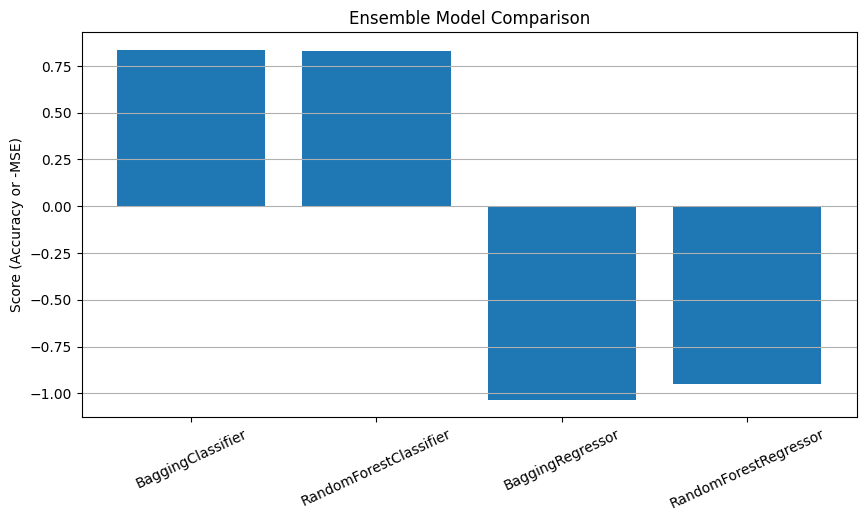

In [29]:
names = ["BaggingClassifier", "RandomForestClassifier", "BaggingRegressor", "RandomForestRegressor"]
scores = [bacc, facc, -bmse, -fmse]

print(scores)
plt.figure(figsize=(10, 5))
plt.bar(names, scores)
plt.title("Ensemble Model Comparison")
plt.ylabel("Score (Accuracy or -MSE)")
plt.xticks(rotation=25)
plt.grid(axis="y")
plt.show()